---
title: "Correlation and Regression"
subtitle: "TA 7"
execute:
  # echo: false
  freeze: auto  # re-render only when source changes
format:
  html:
    code-fold: false
    code-summary: "Show the code"
---

## Dependence between variables 

1. Correlation and regression
1. Linear regression -- OLS


### 1. Correlation and Regression

* Pearson’s coefficient measures linear correlation (r).
* Spearman coefficient compares the 'ranks' of data. 
* NumPy, SciPy, and Pandas all have functions that can be used to calculate these coefficients.

### Correlation in Numpy (Pearson's r)

Required packages


In [30]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Let's make up some numbers


In [2]:
mu, sigma = 0, 0.1 # mean and standard deviation
x = np.random.normal(mu, sigma, 50)
y = np.random.normal(mu, sigma, 50)
z = np.random.normal(mu, sigma, 50)

What does our data look like?


[Text(0.5, 0, 'X'), Text(0, 0.5, 'Y')]

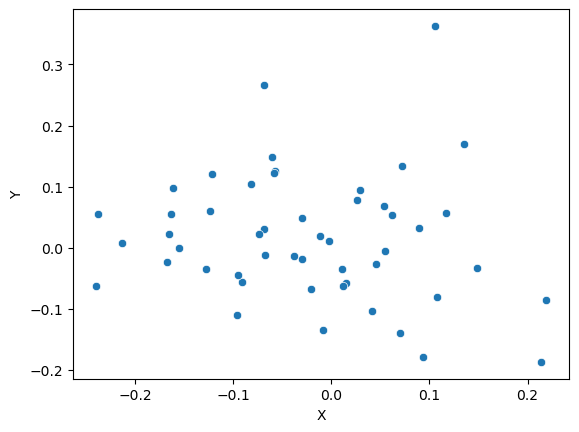

In [31]:
fig, ax = plt.subplots()
sns.scatterplot(x=x, y=y, ax=ax)
ax.set(xlabel='X', ylabel='Y')

Use Numpy to get pearson's correlation between `x` and `y`

In [32]:
np.corrcoef(x, y)

array([[ 1.        , -0.12455511],
       [-0.12455511,  1.        ]])

### The result is a correlation matrix. Each cell in the table shows the correlation between two variables.

* The values on the main diagonal of the correlation matrix (upper left and lower right) are equal to 1. These corresponds to the correlation coefficient for `x` and `x` and `y` and `y`, so they will always be equal to 1.

* The values on the bottom left and top right show the pearson's correlation coefficient for `x` and `y`.




We can do the same thing with more than two variables


In [33]:
np.corrcoef([x, y, z])

array([[ 1.        , -0.12455511,  0.03365426],
       [-0.12455511,  1.        , -0.14554429],
       [ 0.03365426, -0.14554429,  1.        ]])

## Correlation in SciPy (Pearson and Spearman)

Import required packages


In [34]:
import scipy.stats

In [35]:
# pearson
scipy.stats.pearsonr(x, y)

PearsonRResult(statistic=-0.12455510674830719, pvalue=0.3887841983709771)

In [36]:
# spearman
scipy.stats.spearmanr(x, y)

SignificanceResult(statistic=-0.13661464585834332, pvalue=0.34413653070929573)

#### Note: these functions return both the correlation coefficient and the p-value

## Correlation in Pandas

 Time for some real data :)

### Today's dataset: Birthweight

This dataset contains information on new born babies and their parents. 

https://www.sheffield.ac.uk/mash/statistics/datasets

Required packages


In [37]:
import pandas as pd

In [38]:
# import dataset
file = "./birthweight.csv"
df = pd.read_csv(file)

In [79]:
df.head()

,Length,Birthweight,Headcirc,Gestation,smoker,mage,mnocig,mheight,mppwt,fage,fedyrs,fnocig,fheight,lowbwt,mage35
0,56,4.55,34,44,0,20,0,162,57,23,10,35,179,0,0
1,53,4.32,36,40,0,19,0,171,62,19,12,0,183,0,0
2,58,4.10,39,41,0,35,0,172,58,31,16,25,185,0,1
3,53,4.07,38,44,0,20,0,174,68,26,14,25,189,0,0
4,54,3.94,37,42,0,24,0,175,66,30,12,0,184,0,0


### Is there any correlation between birthweight and head circumfrence?

<Axes: xlabel='Birthweight', ylabel='Headcirc'>

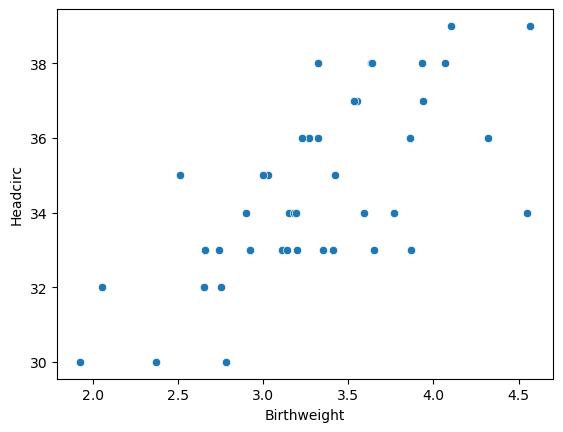

In [42]:
# First, let's visualize the data
sns.scatterplot(x=df['Birthweight'], y=df['Headcirc'])

In [43]:
df['Birthweight'].corr(df['Headcirc'])

0.6846156184774087

### There are lots of ways to calculate correlation in Pandas...

In [44]:
df['Birthweight'].corr(df['Headcirc'],
                       method='pearson')

0.6846156184774087

In [45]:
df['Birthweight'].corr(df['Headcirc'],
                       method='spearman')

0.6772599775176383

### We can also find the correlation between all the variables in our dataframe at once

In [46]:
pearsoncorr = df.corr(method ='pearson')
pearsoncorr

,Length,Birthweight,Headcirc,Gestation,smoker,mage,mnocig,mheight,mppwt,fage,fedyrs,fnocig,fheight,lowbwt,mage35
Length,1.000000,0.726833,0.563172,0.705111,-1.534062e-01,0.075268,-0.039843,0.484992,3.981974e-01,0.137184,0.079485,0.008800,0.208358,-0.609928,0.130502
Birthweight,0.726833,1.000000,0.684616,0.708303,-3.142339e-01,0.000173,-0.152335,0.363055,4.008856e-01,0.175710,0.071045,-0.093136,0.031022,-0.651964,-0.108947
Headcirc,0.563172,0.684616,1.000000,0.404635,-1.828719e-01,0.145842,-0.132988,0.337047,3.028541e-01,0.301151,0.123892,-0.046837,0.041509,-0.446849,0.055386
Gestation,0.705111,0.708303,0.404635,1.000000,-9.474608e-02,0.010778,0.043195,0.210503,2.550824e-01,0.142175,0.130987,-0.113831,0.207597,-0.602935,0.007395
smoker,-0.153406,-0.314234,-0.182872,-0.094746,1.000000e+00,0.212479,0.727218,0.000353,9.808342e-16,0.197501,-0.014891,0.417633,0.110633,0.253012,0.146938
mage,0.075268,0.000173,0.145842,0.010778,2.124788e-01,1.000000,0.340294,0.059956,2.741677e-01,0.806584,0.441683,0.090927,-0.199547,-0.076394,0.692664
mnocig,-0.039843,-0.152335,-0.132988,0.043195,7.272181e-01,0.340294,1.000000,0.126439,1.489446e-01,0.248425,0.198526,0.257307,0.020672,0.035384,0.290574
mheight,0.484992,0.363055,0.337047,0.210503,3.532676e-04,0.059956,0.126439,1.000000,6.806217e-01,-0.079870,0.035297,0.048398,0.274338,-0.198151,0.116002
mppwt,0.398197,0.400886,0.302854,0.255082,9.808342e-16,0.274168,0.148945,0.680622,1.000000e+00,0.255706,0.180374,0.057163,0.092983,-0.353974,0.136853
fage,0.137184,0.175710,0.301151,0.142175,1.975014e-01,0.806584,0.248425,-0.079870,2.557058e-01,1.000000,0.300471,0.135862,-0.269377,-0.245095,0.351405


### That isn't so helpful... we can also make a heatmap to display the data visually

<Axes: >

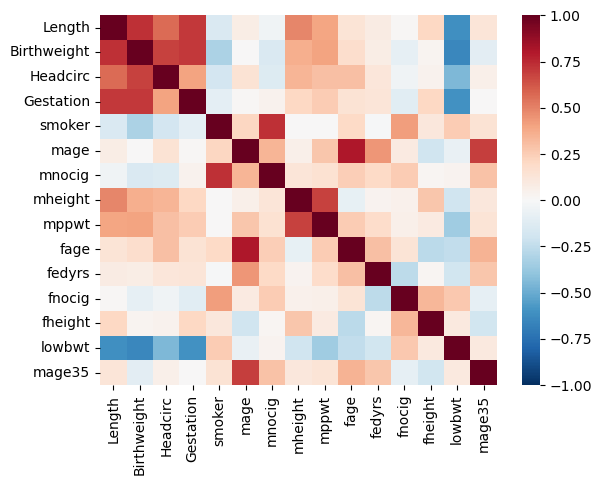

In [49]:
fig, ax = plt.subplots()

sns.heatmap(pearsoncorr,
           cmap='RdBu_r', ax=ax, vmin=-1, vmax=1)


## Linear Regression 

In statistics, linear regression is a linear approach to modeling the relationship between a scalar response and one or more explanatory variables (also known as dependent and independent variables).

https://en.wikipedia.org/wiki/Linear_regression

We have a lot of options for for studying linear regression

### Scipy.stats

In [50]:
result = scipy.stats.linregress(df['Birthweight'],
                                df['Headcirc'])

In [52]:
print(result)

LinregressResult(slope=2.720563928236349, intercept=25.58239845298082, rvalue=0.6846156184774087, pvalue=5.734797978444235e-07, stderr=0.45798646115832675, intercept_stderr=1.5416553949208147)


A reminder of what the data look like...

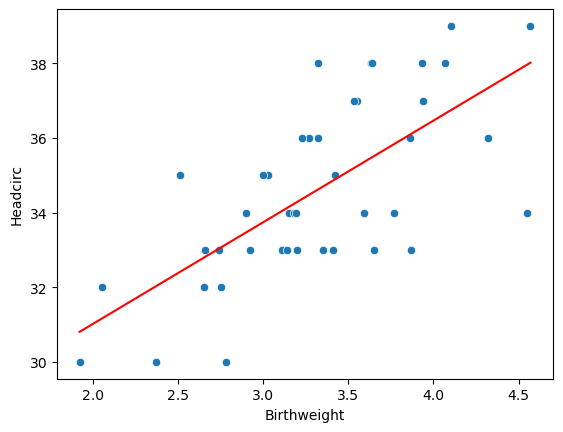

In [62]:
fig, ax = plt.subplots()
sns.scatterplot(x=df['Birthweight'], y=df['Headcirc'], ax=ax)
x = np.linspace(df['Birthweight'].min(), df['Birthweight'].max(), 100)
y = result.intercept + result.slope * x
ax.plot(x, y, color='red')






In [54]:
result.slope

2.720563928236349

In [55]:
result.intercept

25.58239845298082

In [63]:
result.rvalue**2

0.46869854506320485

### Using sklearn

In [64]:
from sklearn import linear_model

In [65]:
my_model = linear_model.LinearRegression()
results = my_model.fit(df[['Birthweight']], df[['Headcirc']])
print("The linear model is: Y = {:.5} + {:.5}X".format(results.intercept_[0],
                                                       results.coef_[0][0]))

The linear model is: Y = 25.582 + 2.7206X


In [58]:
# the results are the same, but the sklearn package has some other features
predictions = results.predict(df[['Birthweight']])

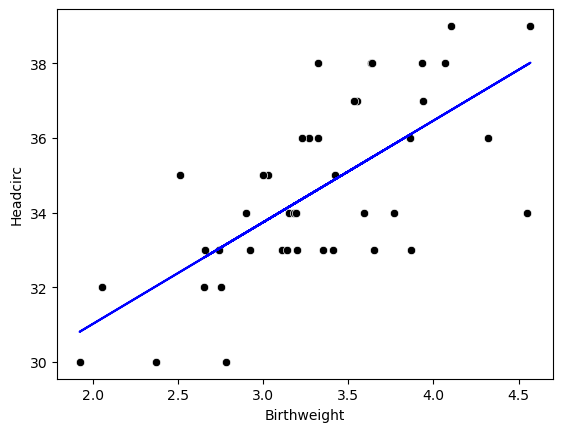

In [67]:
fig, ax = plt.subplots()
# we can add the predicted values to the original plot
ax = sns.scatterplot(x=df['Birthweight'], 
                     y=df['Headcirc'],
                     color="0.0")
ax.plot(df['Birthweight'],
        predictions,
        color="b")

## Hypothesis testing

* Null hypothesis 1: The actual intercept is equal to zero
* Null hypothesis 2: The actual slope is equal to zero

Using the `statsmodels.api` package

In [69]:
import statsmodels.api as sm

Set up the model

In [70]:
X = sm.add_constant(df['Birthweight'])
Y = df['Headcirc']
model = sm.OLS(Y, X)  # OLS = ordinary least squares
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:               Headcirc   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     35.29
Date:                Tue, 16 Jul 2024   Prob (F-statistic):           5.73e-07
Time:                        09:12:12   Log-Likelihood:                -82.574
No. Observations:                  42   AIC:                             169.1
Df Residuals:                      40   BIC:                             172.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          25.5824      1.542     16.594      

#### The P-value is the answer to the question "how likely is it that we’d get a test statistic t* as extreme as we did if the null hypothesis were true?

Does this output correspond to a one-tailed or two-tailed test?

If we want to test whether the slope is different from 0, we need a two-sided test.

If we want to test a specific direction, we can use a one-sided test. To do this, we need to divide the p-value in the table above in half.

Read more: https://stats.idre.ucla.edu/other/mult-pkg/faq/general/faq-what-are-the-differences-between-one-tailed-and-two-tailed-tests/  



In [77]:
print(f'p value of the intercept: {results.pvalues.iloc[0]}, p value of the slope: {results.pvalues.iloc[1]}')

p value of the intercept: 1.5527553380020346e-19, p value of the slope: 5.734797978444454e-07


#### Can we compute the P-value using permutations?.... YES!